# Task
Perform data analysis on the "Life Expectancy Data.csv" dataset in Python, including data loading, cleaning, exploratory data analysis (EDA), statistical analysis, and visualization.

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df_life = pd.read_csv('Life Expectancy Data.csv')
display(df_life.head())

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Data loading


## Initial data inspection




In [25]:
display(df_life.head())
display(df_life.info())
display(df_life.isnull().sum())

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

None

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [4]:
# Calculate the percentage of missing values for each column
missing_percentages = df_life.isnull().sum() / len(df_life) * 100
display("Percentage of missing values per column:")
display(missing_percentages)

# Strategy to handle missing values:
# - Drop columns with a high percentage of missing values (e.g., > 50%)
# - Impute missing values for other columns using appropriate methods (e.g., median for numerical, mode for categorical)

# Identify columns to drop based on a threshold (e.g., 50%)
cols_to_drop = missing_percentages[missing_percentages > 50].index
df_life_cleaned = df_life.drop(columns=cols_to_drop)
display(f"Columns dropped due to high missing percentage: {list(cols_to_drop)}")

# Impute missing values for remaining columns
for col in df_life_cleaned.columns:
    if df_life_cleaned[col].isnull().any():
        if df_life_cleaned[col].dtype in ['float64', 'int64']:
            # Impute numerical columns with the median
            median_val = df_life_cleaned[col].median()
            df_life_cleaned[col].fillna(median_val, inplace=True)
            display(f"Imputed missing values in '{col}' with median ({median_val}).")
        else:
            # Impute categorical columns with the mode
            mode_val = df_life_cleaned[col].mode()[0]
            df_life_cleaned[col].fillna(mode_val, inplace=True)
            display(f"Imputed missing values in '{col}' with mode ({mode_val}).")

# Verify that the missing values have been handled
display("Missing values after handling:")
display(df_life_cleaned.isnull().sum())

df_life = df_life_cleaned # Update the original dataframe

'Percentage of missing values per column:'

,0
Country,0.000000
Year,0.000000
Status,0.000000
Life expectancy,0.340368
Adult Mortality,0.340368
infant deaths,0.000000
Alcohol,6.603131
percentage expenditure,0.000000
Hepatitis B,18.822328
Measles,0.000000


'Columns dropped due to high missing percentage: []'

/tmp/ipython-input-492830977.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_life_cleaned[col].fillna(median_val, inplace=True)


"Imputed missing values in 'Life expectancy ' with median (72.1)."

...

"Imputed missing values in ' thinness 5-9 years' with median (3.3)."

"Imputed missing values in 'Income composition of resources' with median (0.677)."

"Imputed missing values in 'Schooling' with median (12.3)."

'Missing values after handling:'

,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


## Handle missing values


In [23]:
display(df_life.info())
# Generate descriptive statistics for numerical columns
display("Descriptive statistics for numerical columns:")
display(df_life.describe())

# Identify categorical columns
categorical_cols = df_life.select_dtypes(include='object').columns
display(f"Categorical columns: {list(categorical_cols)}")

# Generate frequency counts for categorical columns
display("Frequency counts for categorical columns:")
for col in categorical_cols:
    display(f"Frequency counts for '{col}':")
    display(df_life[col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

None

'Descriptive statistics for numerical columns:'

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.234717,164.725664,30.303948,4.546875,738.251295,83.022124,2419.592240,38.381178,42.035739,82.617767,5.924098,82.393125,1.742103,6611.523863,1.023085e+07,4.821886,4.852144,0.630362,12.009837
std,4.613841,9.509115,124.086215,117.926501,3.921946,1987.914858,22.996984,11467.272489,19.935375,160.445548,23.367166,2.400770,23.655562,5.077785,13296.603449,5.402242e+07,4.397621,4.485854,0.205140,3.265139
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,1.092500,4.685343,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.600000,227.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.772000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


"Categorical columns: ['Country', 'Status']"

'Frequency counts for categorical columns:'

"Frequency counts for 'Country':"

,count
Country,
Afghanistan,16
Albania,16
Algeria,16
Angola,16
Antigua and Barbuda,16
...,...
Monaco,1
Marshall Islands,1
Saint Kitts and Nevis,1


"Frequency counts for 'Status':"

,count
Status,
Developing,2426
Developed,512


## Summary statistics

### Subtask:
Generate descriptive statistics for numerical columns (mean, median, standard deviation, etc.) and frequency counts for categorical columns.


**Reasoning**:
Generate descriptive statistics for numerical columns and frequency counts for categorical columns as requested.



'Descriptive statistics for numerical columns:'

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.234717,164.725664,30.303948,4.546875,738.251295,83.022124,2419.592240,38.381178,42.035739,82.617767,5.924098,82.393125,1.742103,6611.523863,1.023085e+07,4.821886,4.852144,0.630362,12.009837
std,4.613841,9.509115,124.086215,117.926501,3.921946,1987.914858,22.996984,11467.272489,19.935375,160.445548,23.367166,2.400770,23.655562,5.077785,13296.603449,5.402242e+07,4.397621,4.485854,0.205140,3.265139
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,1.092500,4.685343,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.600000,227.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.772000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


"Categorical columns: ['Country', 'Status']"

'Frequency counts for categorical columns:'

"Frequency counts for 'Country':"

,count
Country,
Afghanistan,16
Albania,16
Algeria,16
Angola,16
Antigua and Barbuda,16
...,...
Monaco,1
Marshall Islands,1
Saint Kitts and Nevis,1


"Frequency counts for 'Status':"

,count
Status,
Developing,2426
Developed,512


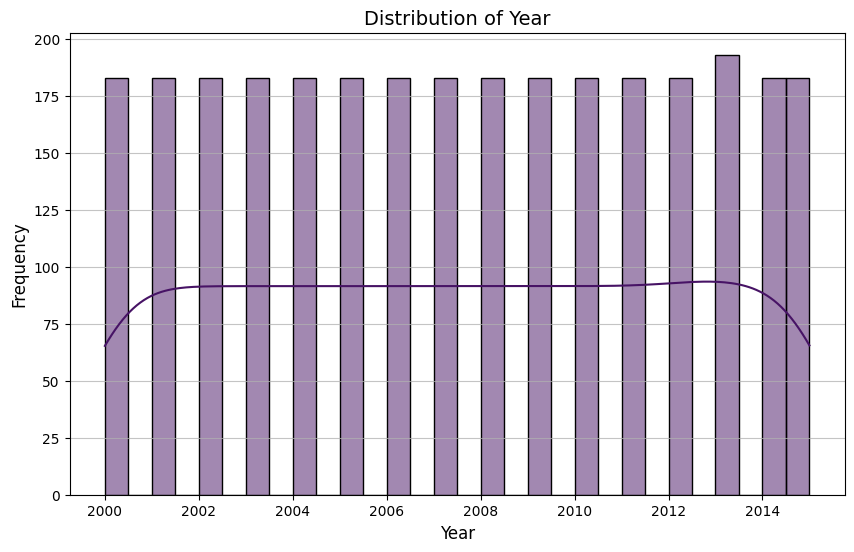

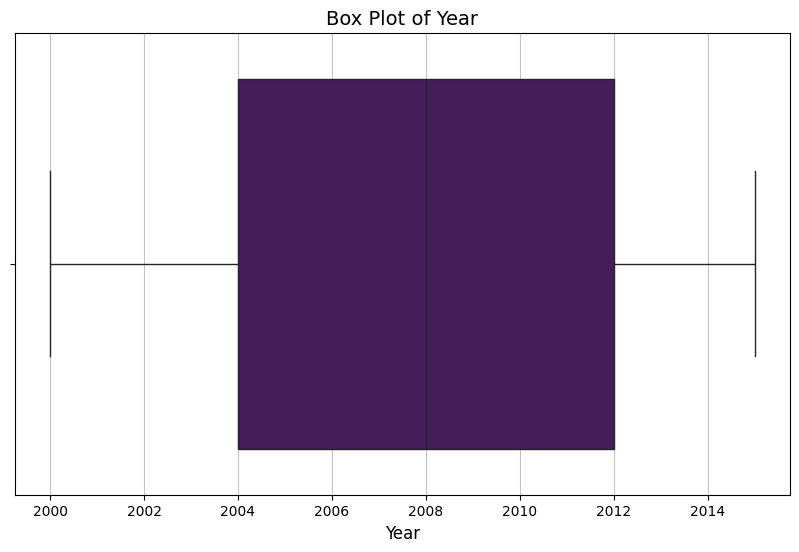

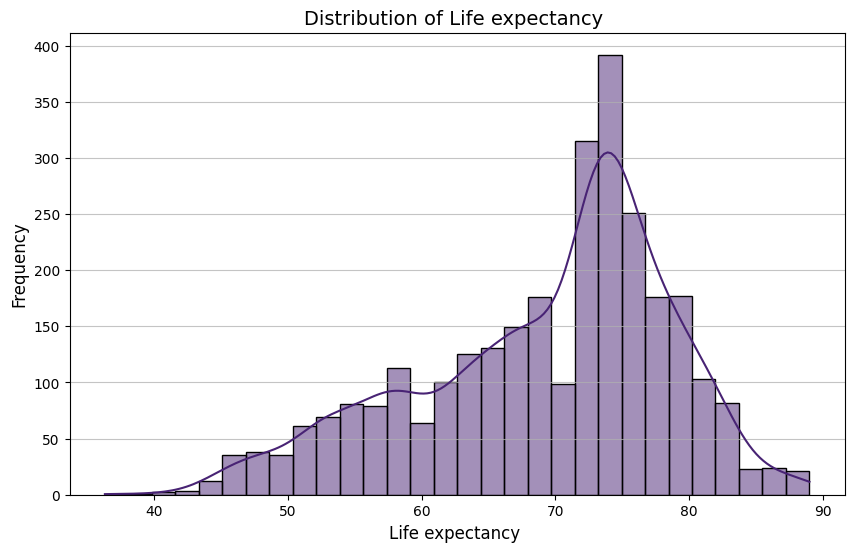

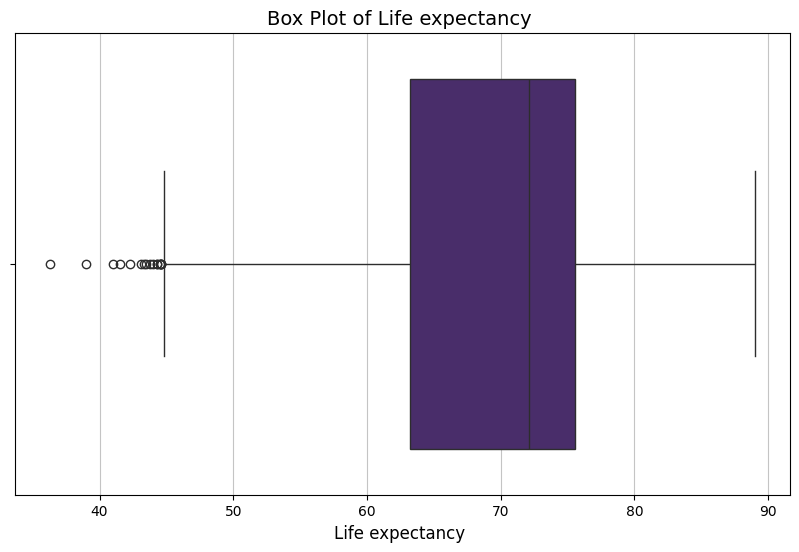

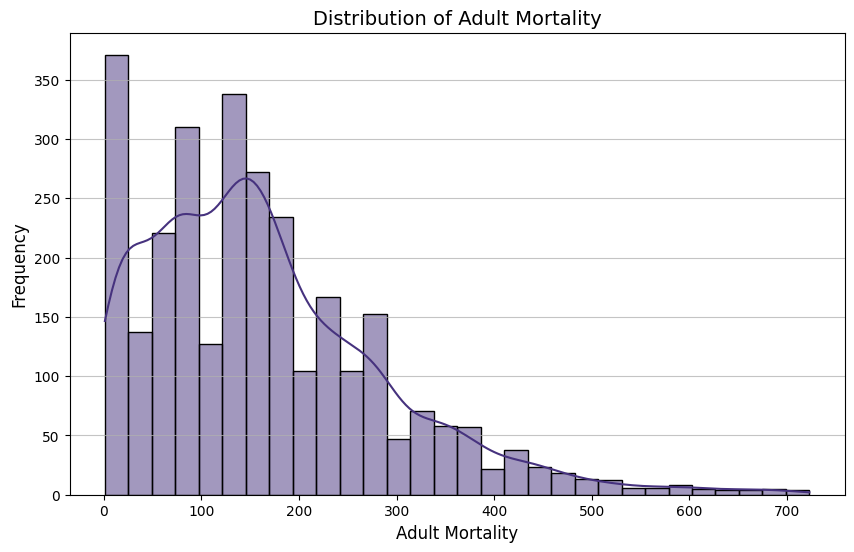

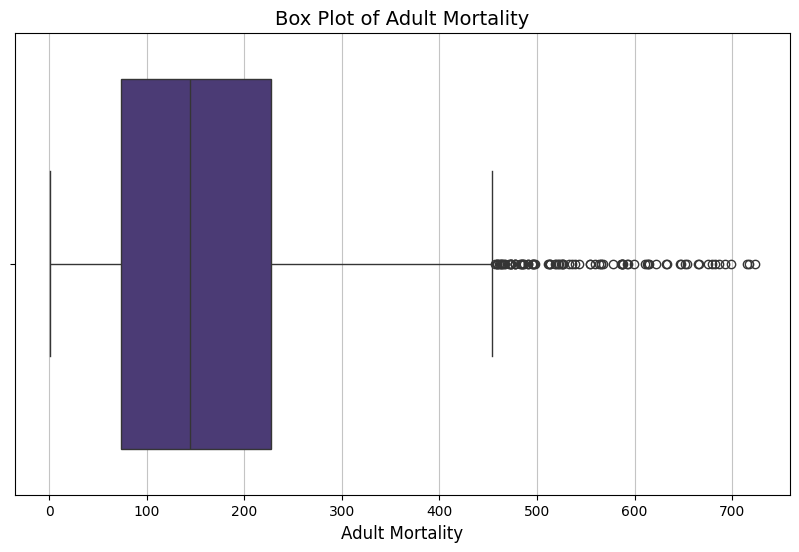

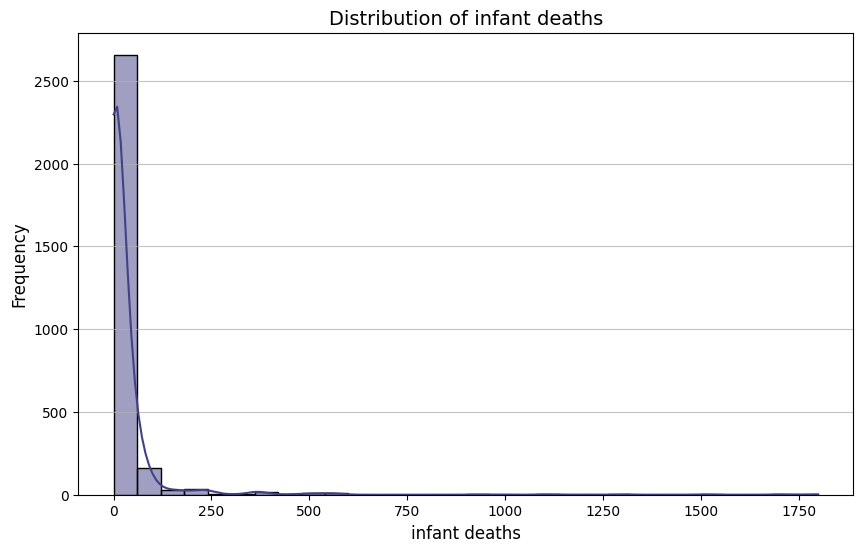

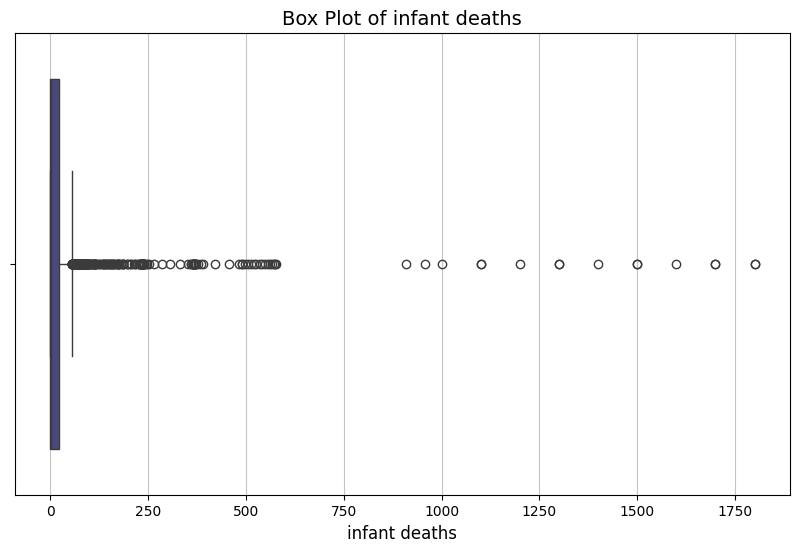

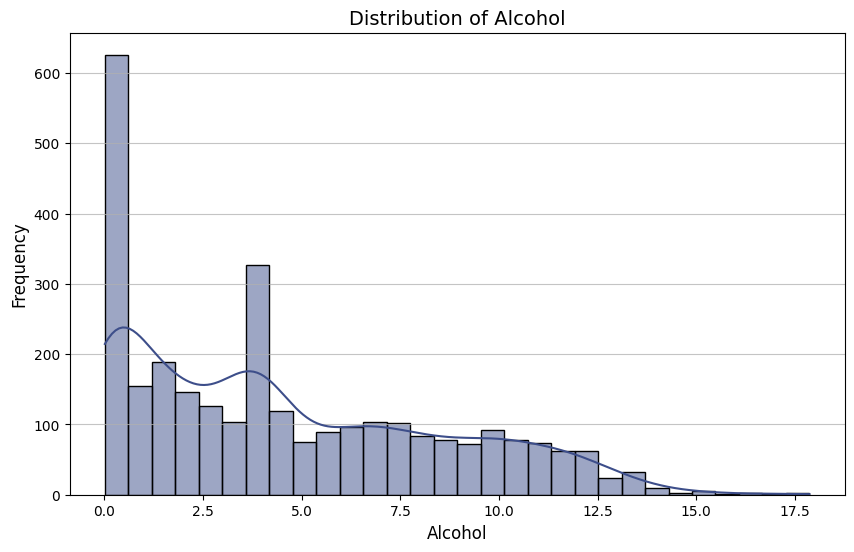

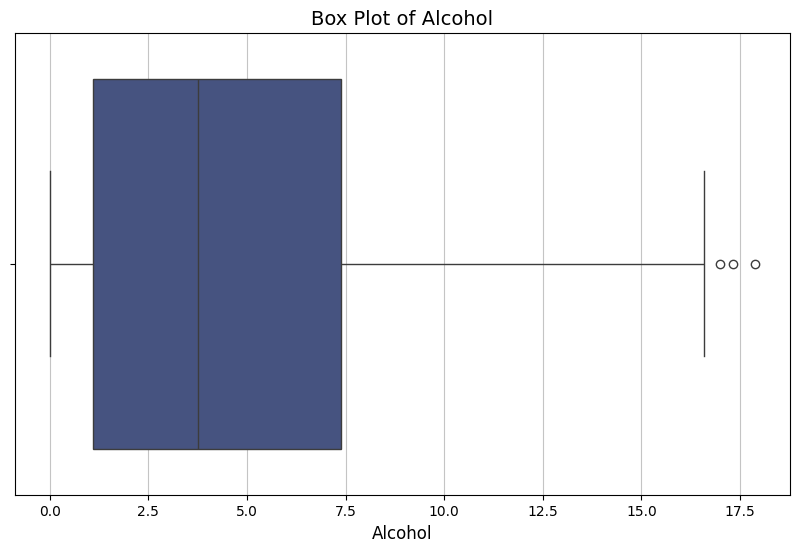

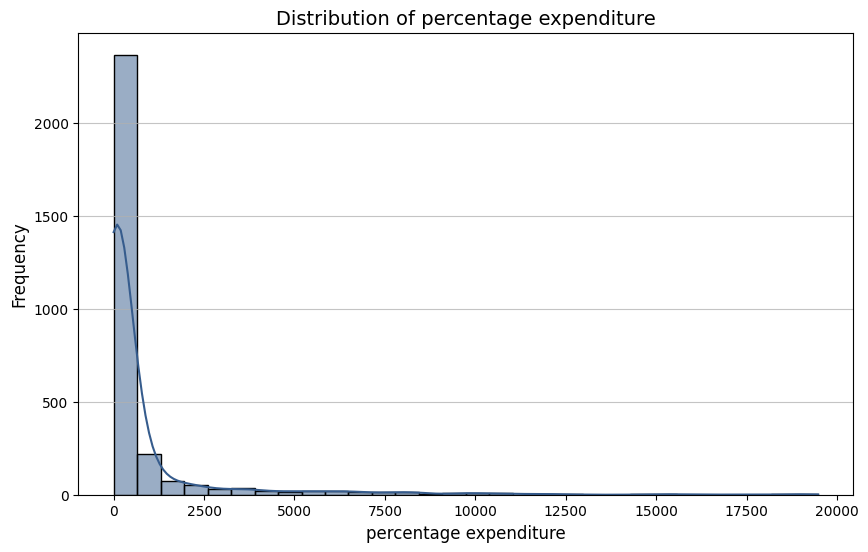

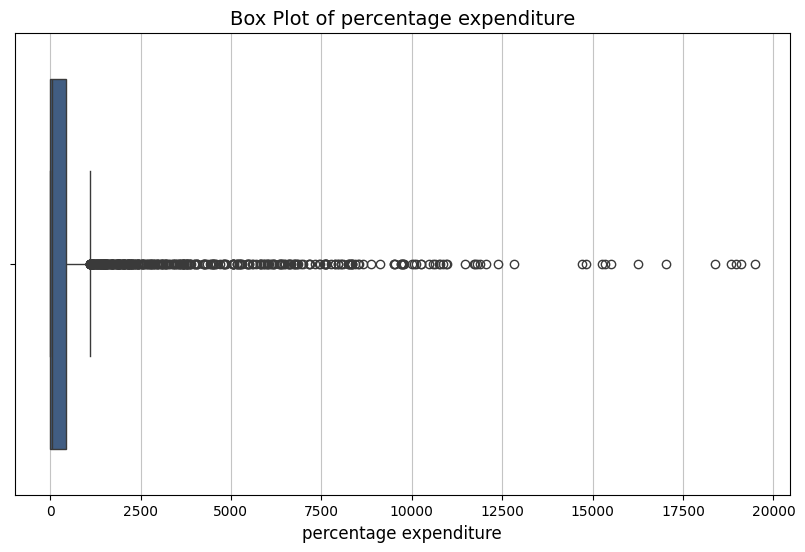

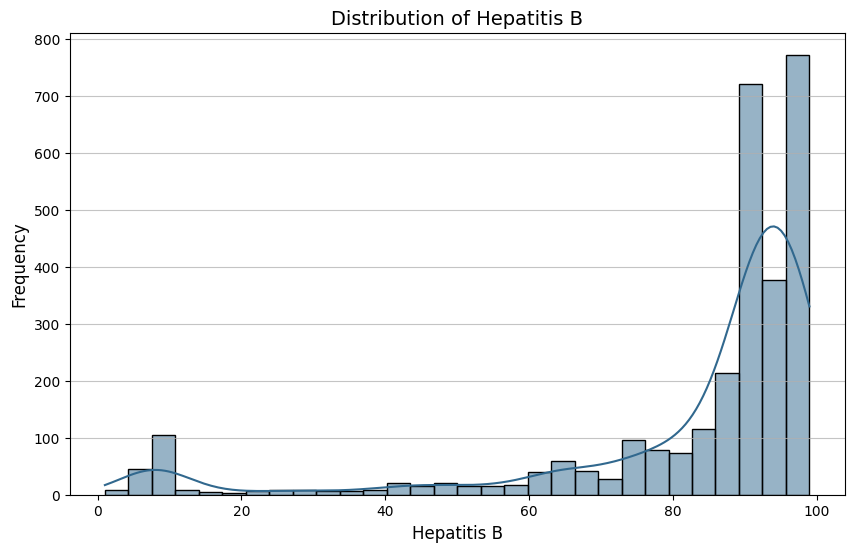

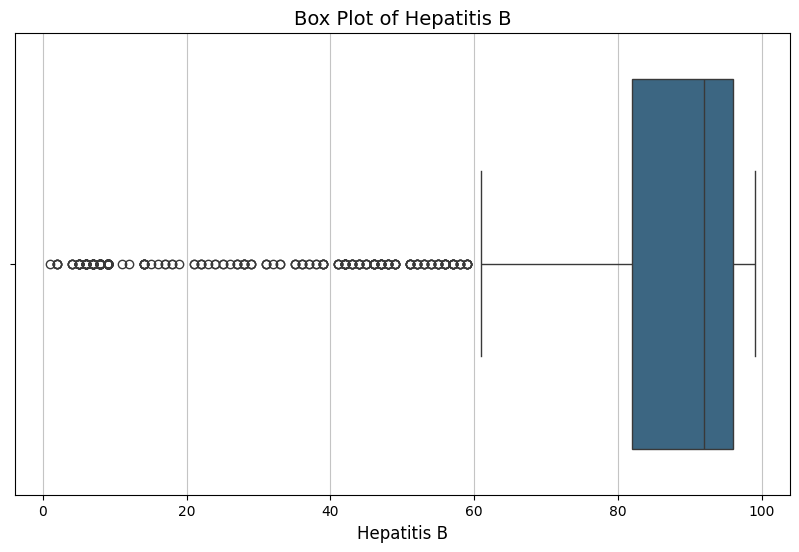

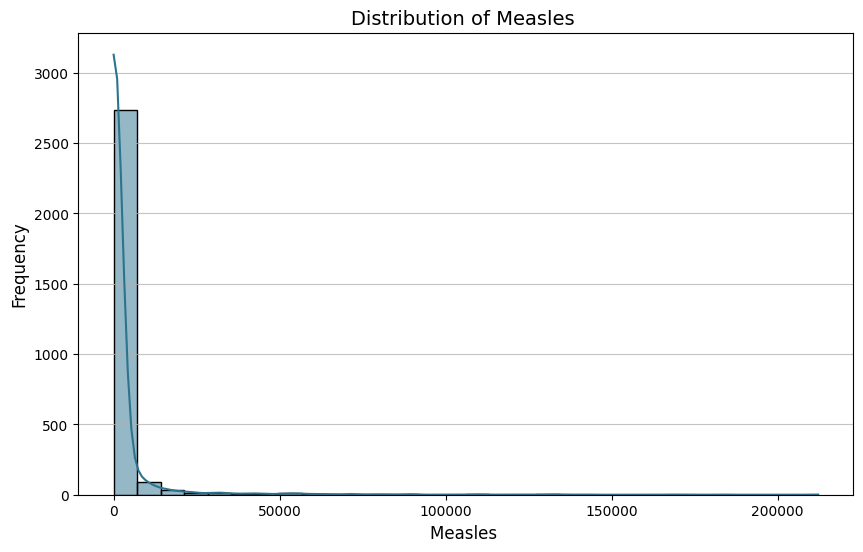

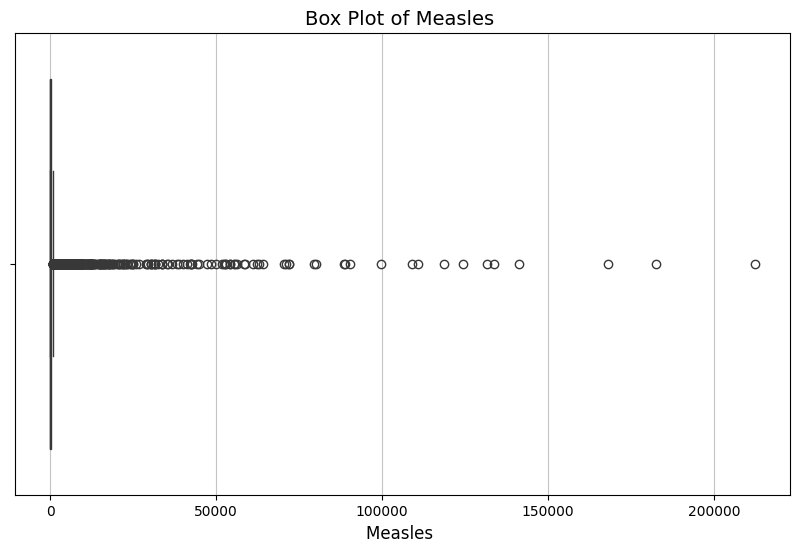

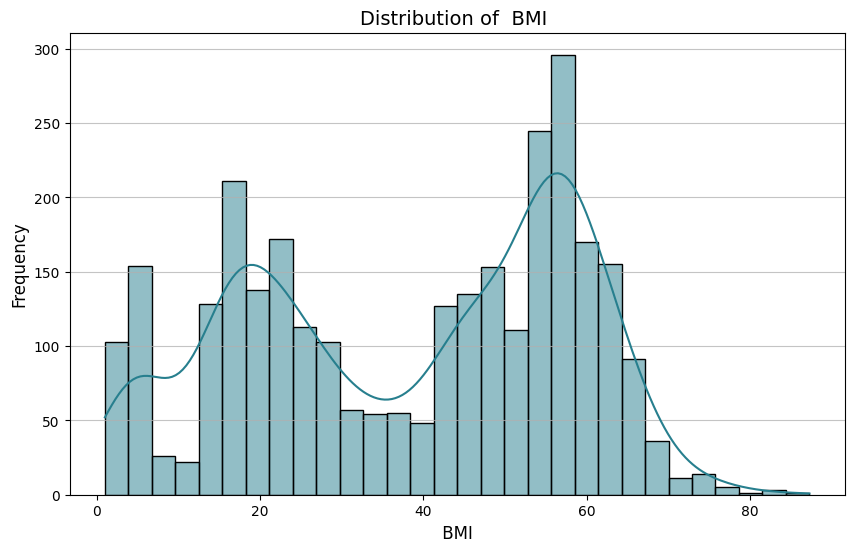

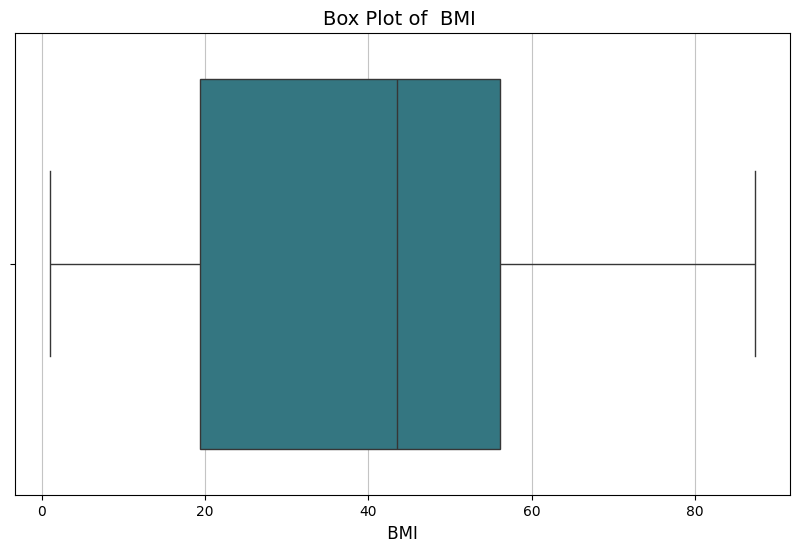

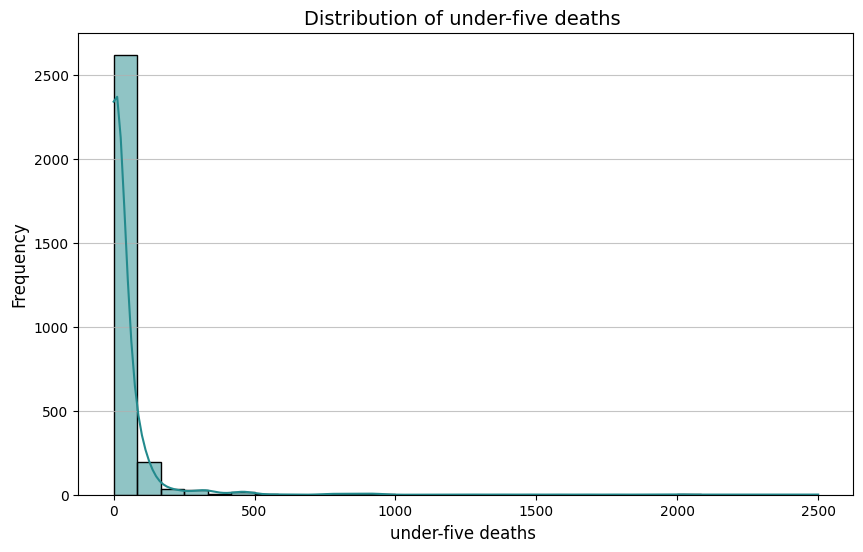

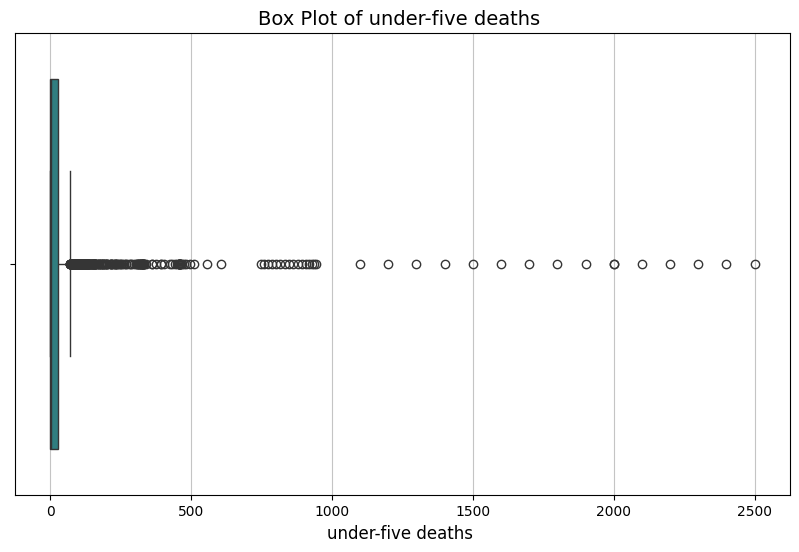

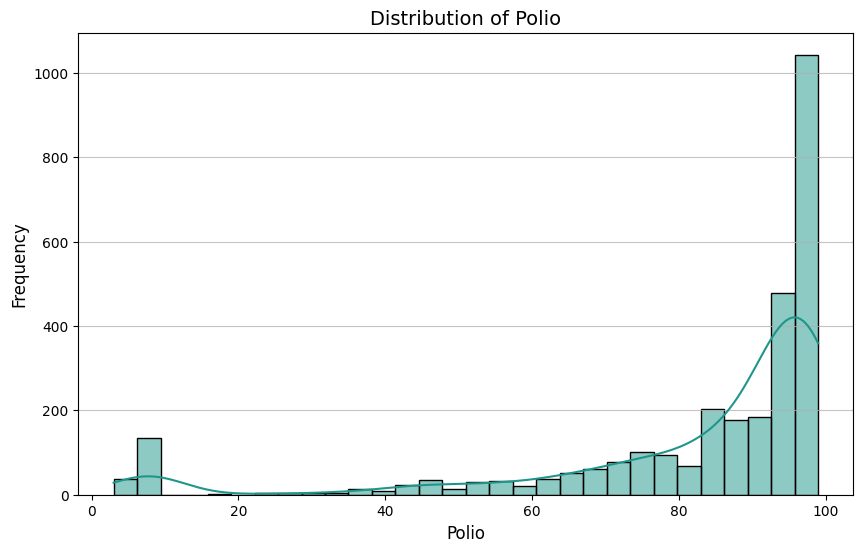

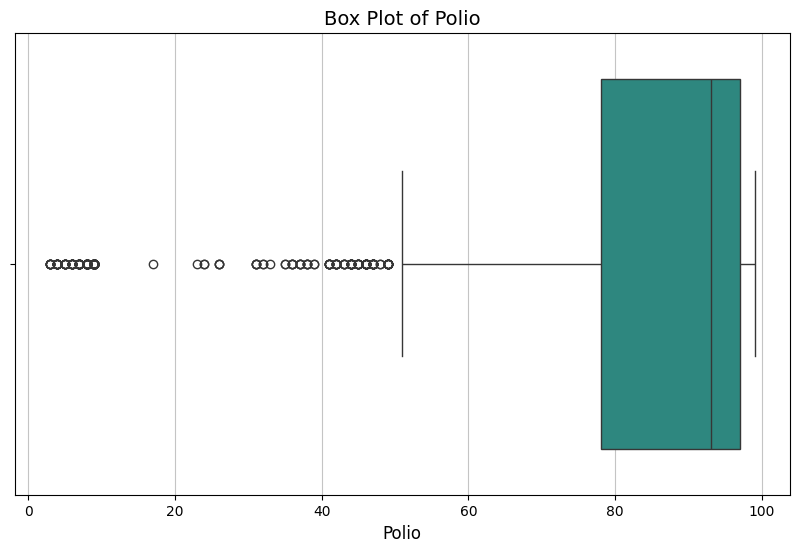

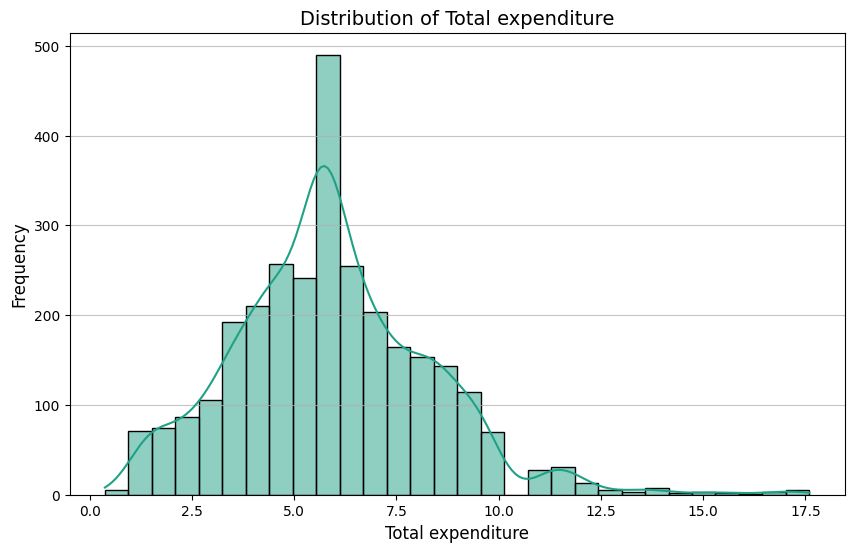

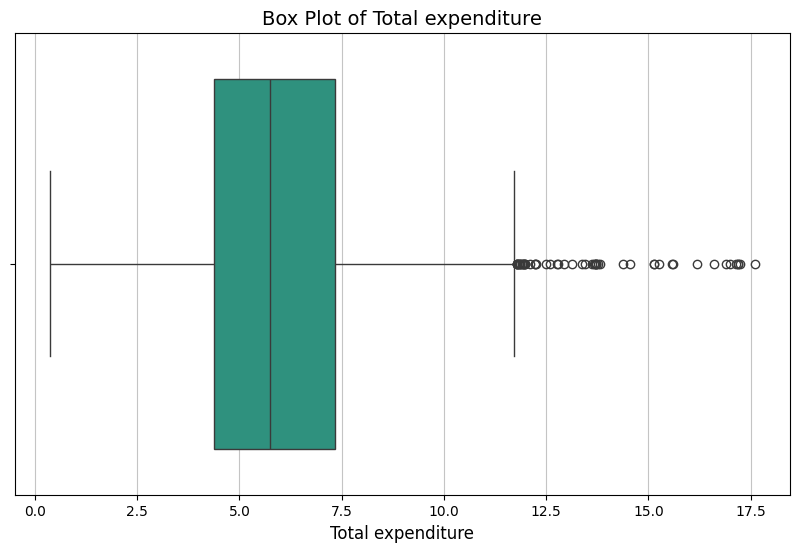

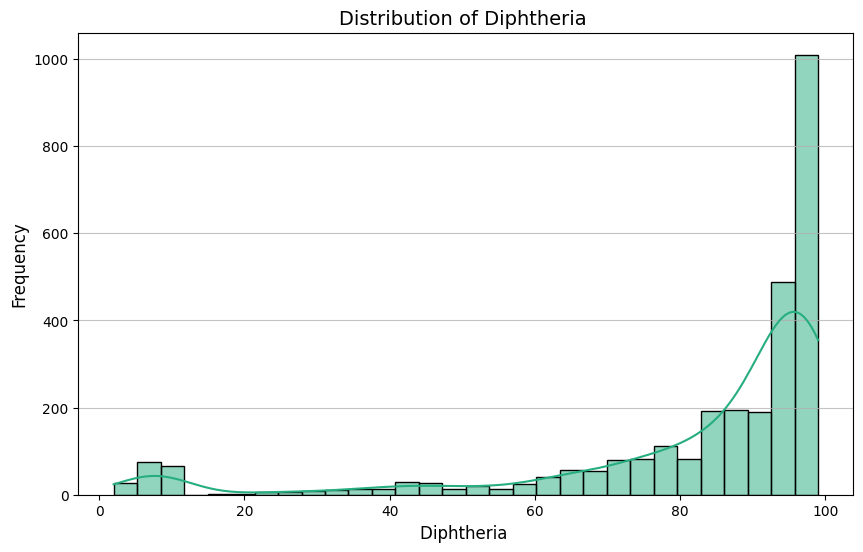

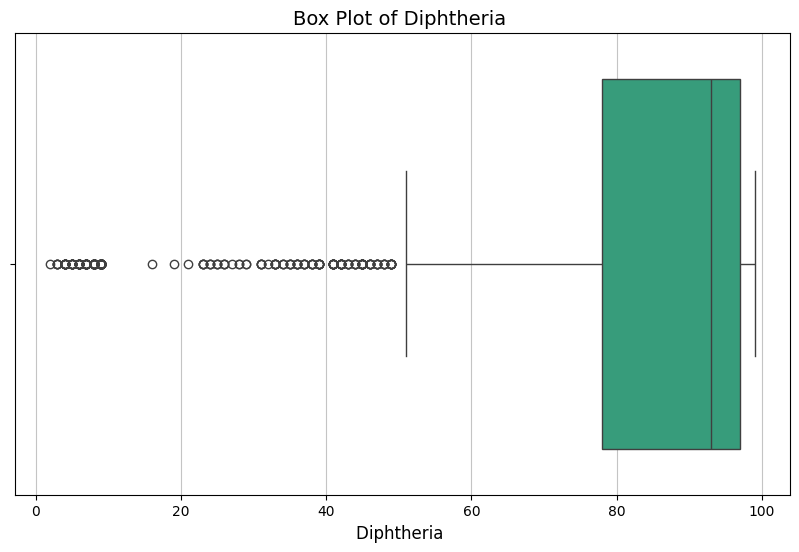

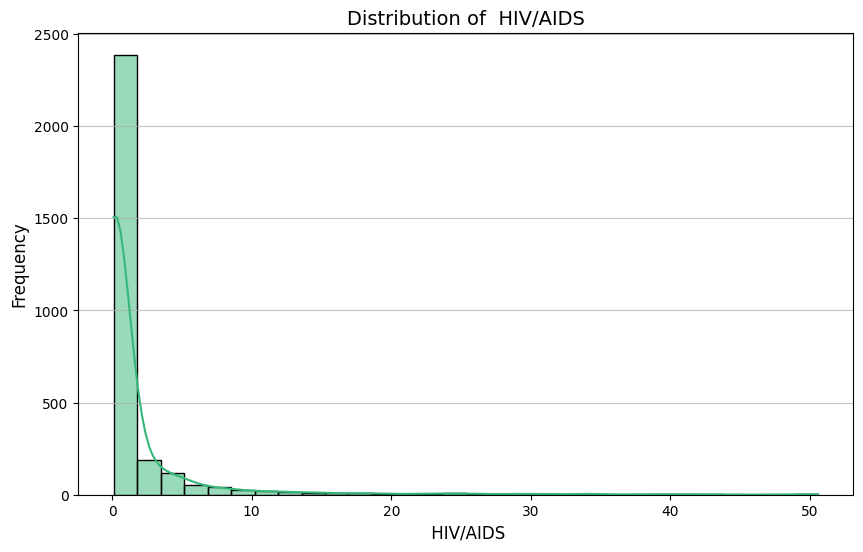

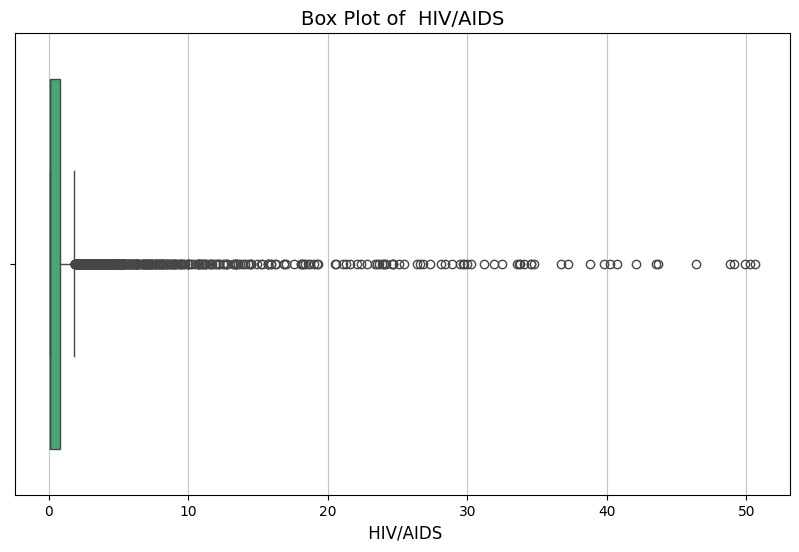

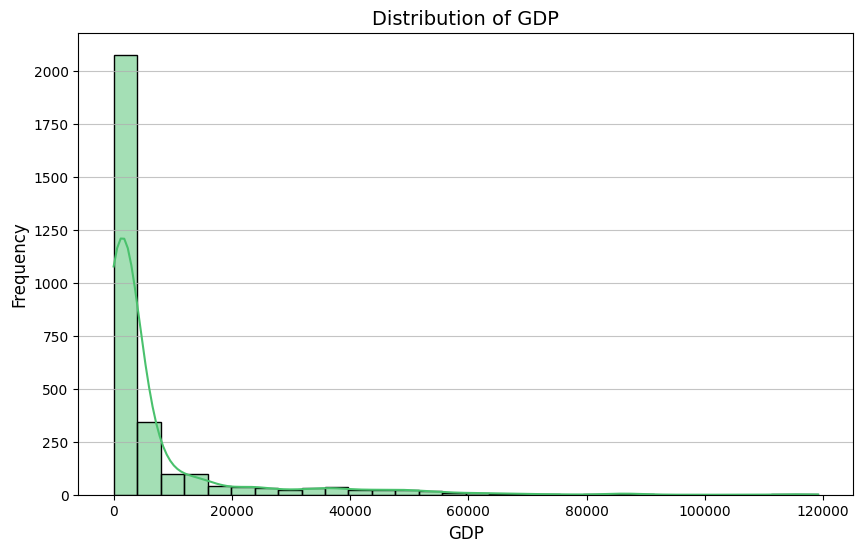

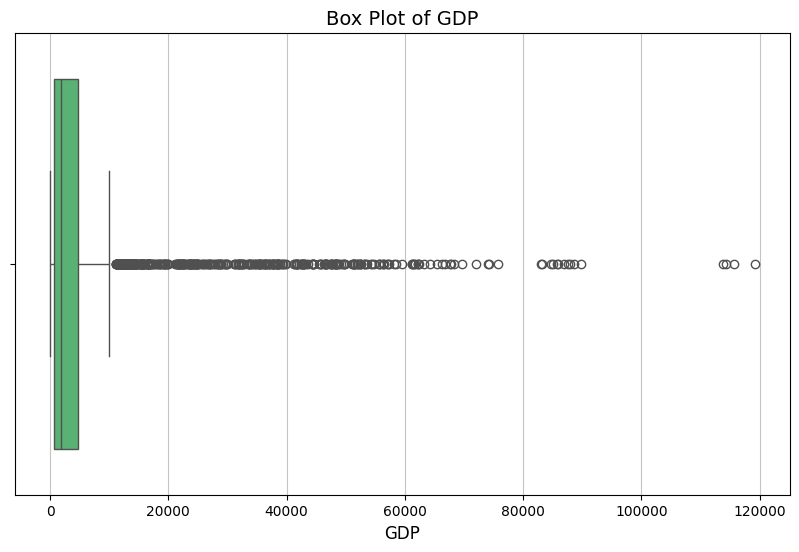

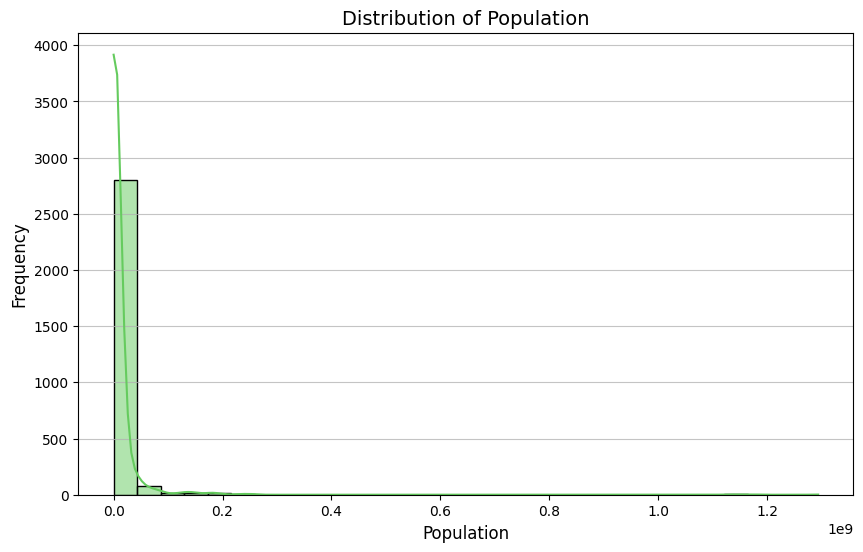

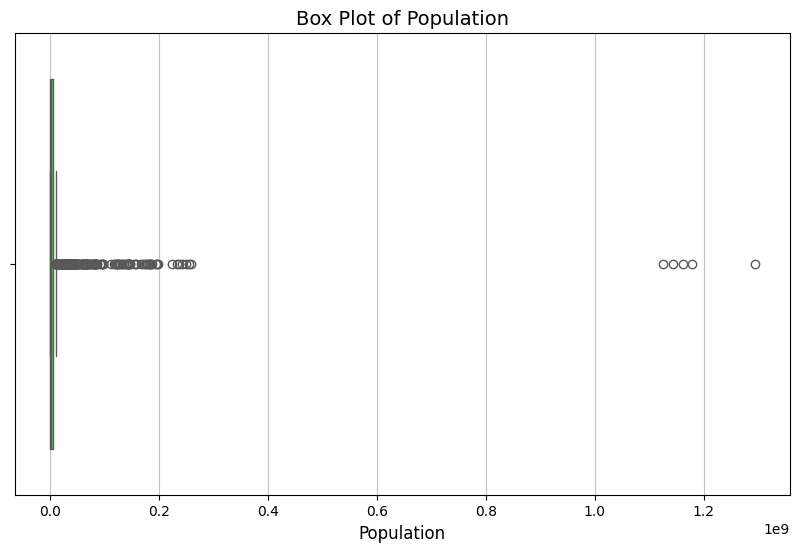

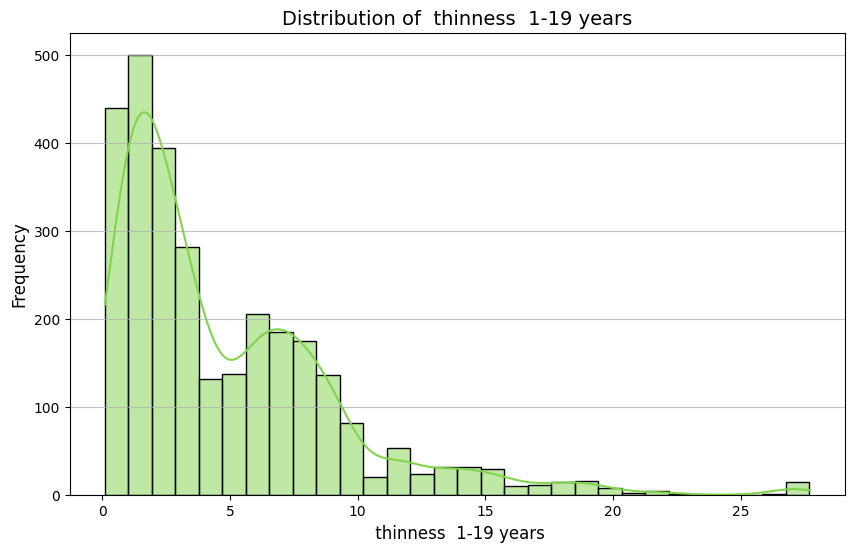

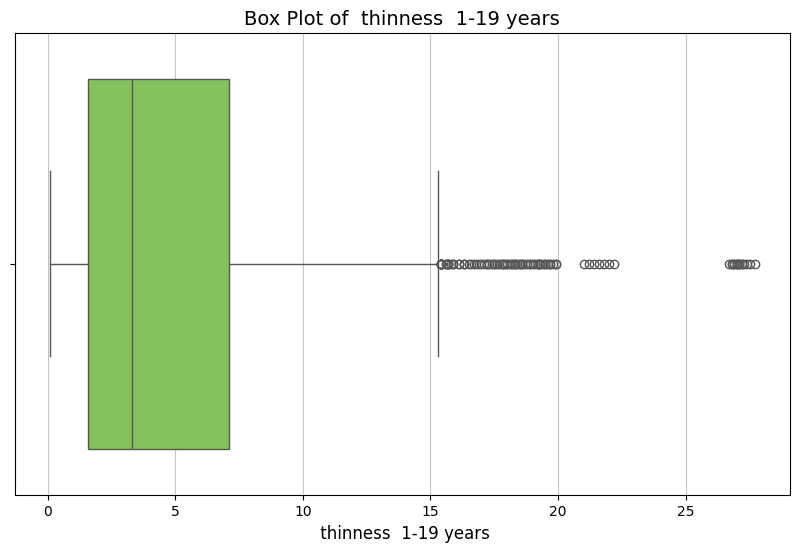

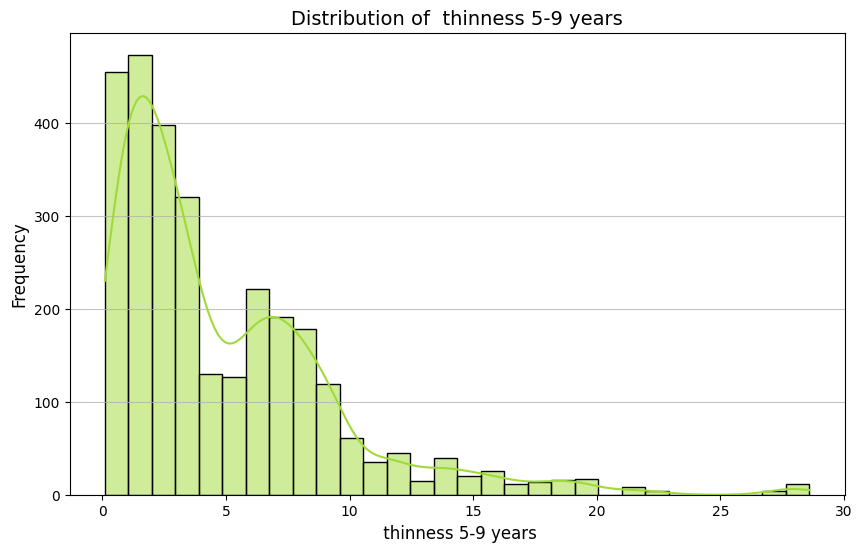

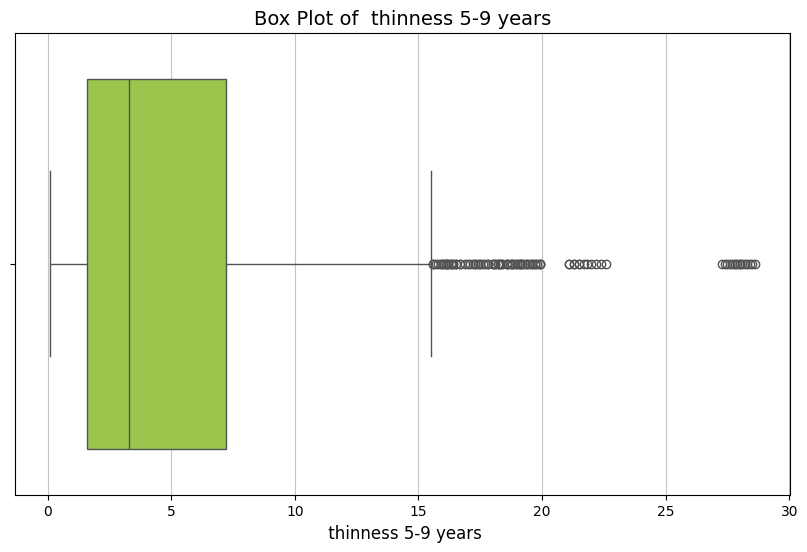

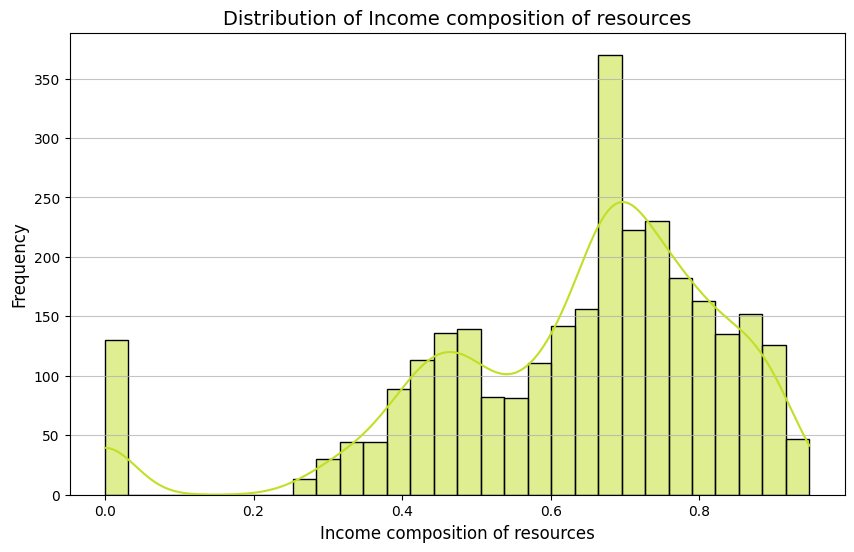

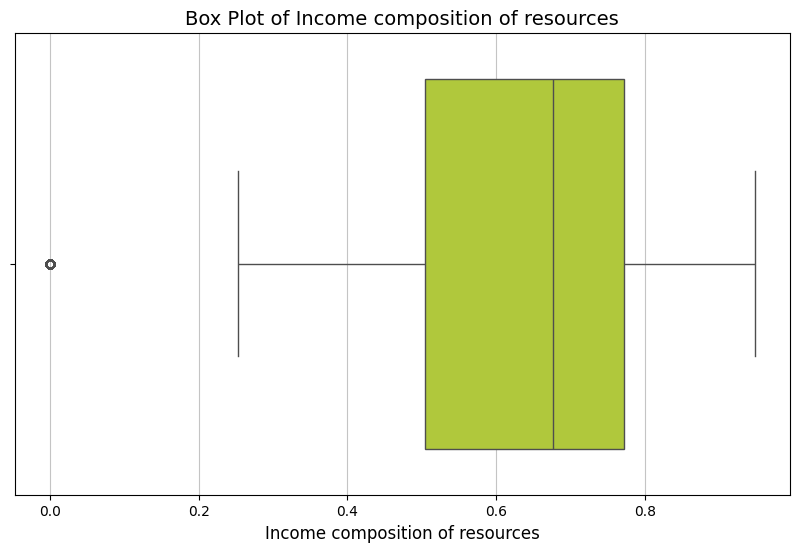

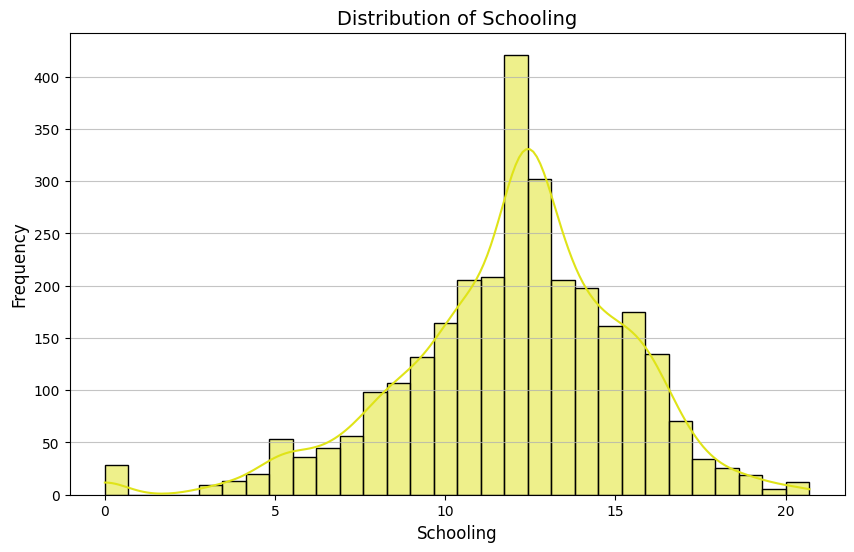

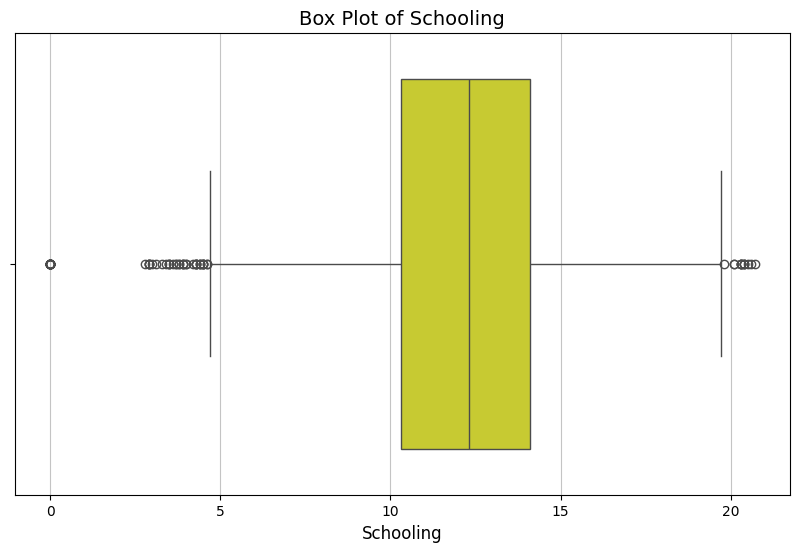

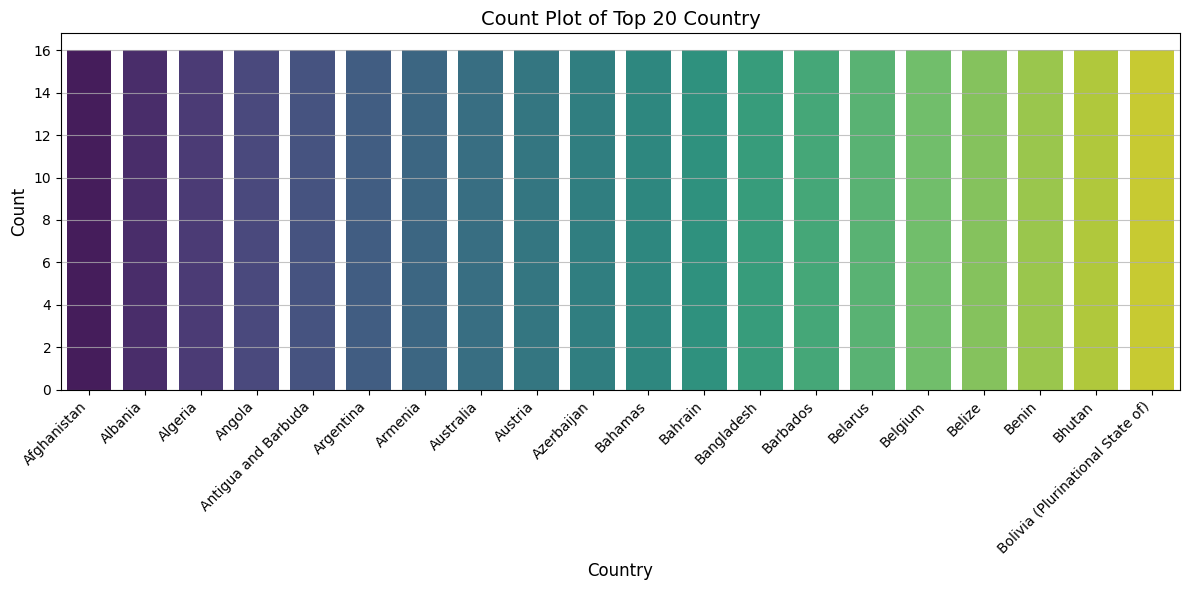

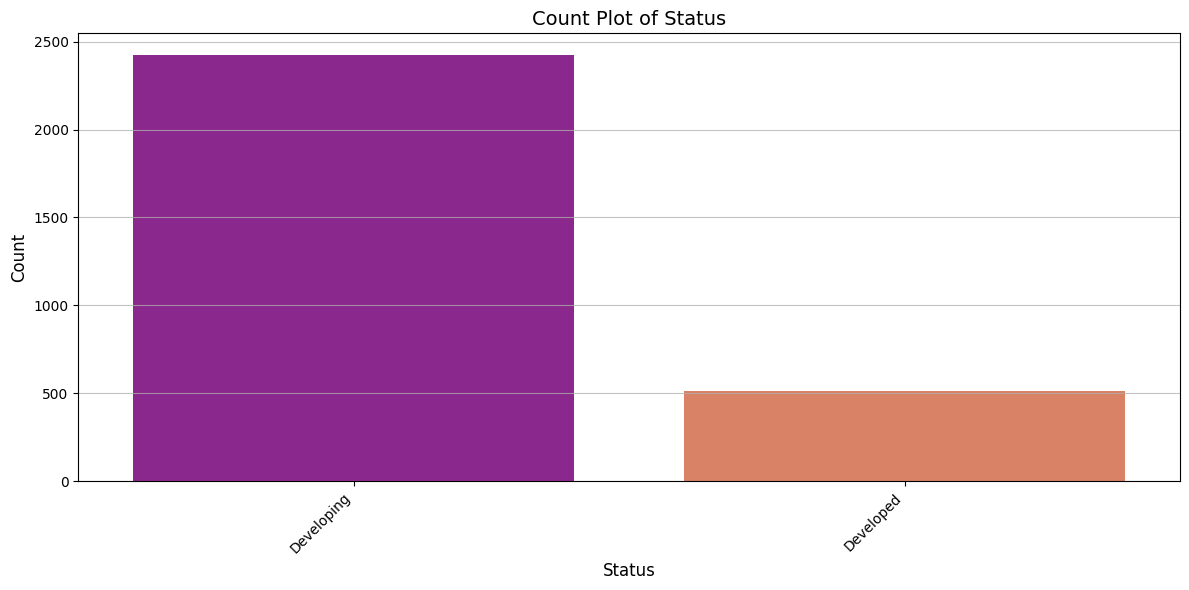

In [20]:
# Identify numerical and categorical columns
numerical_cols = df_life.select_dtypes(include=np.number).columns
categorical_cols = df_life.select_dtypes(include='object').columns

# Define a color palette for the plots
color_palette = sns.color_palette("viridis", len(numerical_cols))

# Plot distributions for numerical columns
for i, col in enumerate(numerical_cols):
    # Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df_life[col], kde=True, color=color_palette[i], bins=30)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Box plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_life[col], color=color_palette[i])
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', alpha=0.75)
    plt.show()

# Plot distributions for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    if col == 'Country':
        # For 'Country', show only the top N countries to avoid an unreadable plot
        top_n = 20
        top_countries = df_life[col].value_counts().nlargest(top_n).index
        sns.countplot(data=df_life[df_life[col].isin(top_countries)], x=col, palette='viridis', order=top_countries, hue=col, legend=False)
        plt.title(f'Count Plot of Top {top_n} {col}', fontsize=14)
    else:
        sns.countplot(data=df_life, x=col, palette='plasma', hue=col, legend=False)
        plt.title(f'Count Plot of {col}', fontsize=14)

    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## Univariate analysis




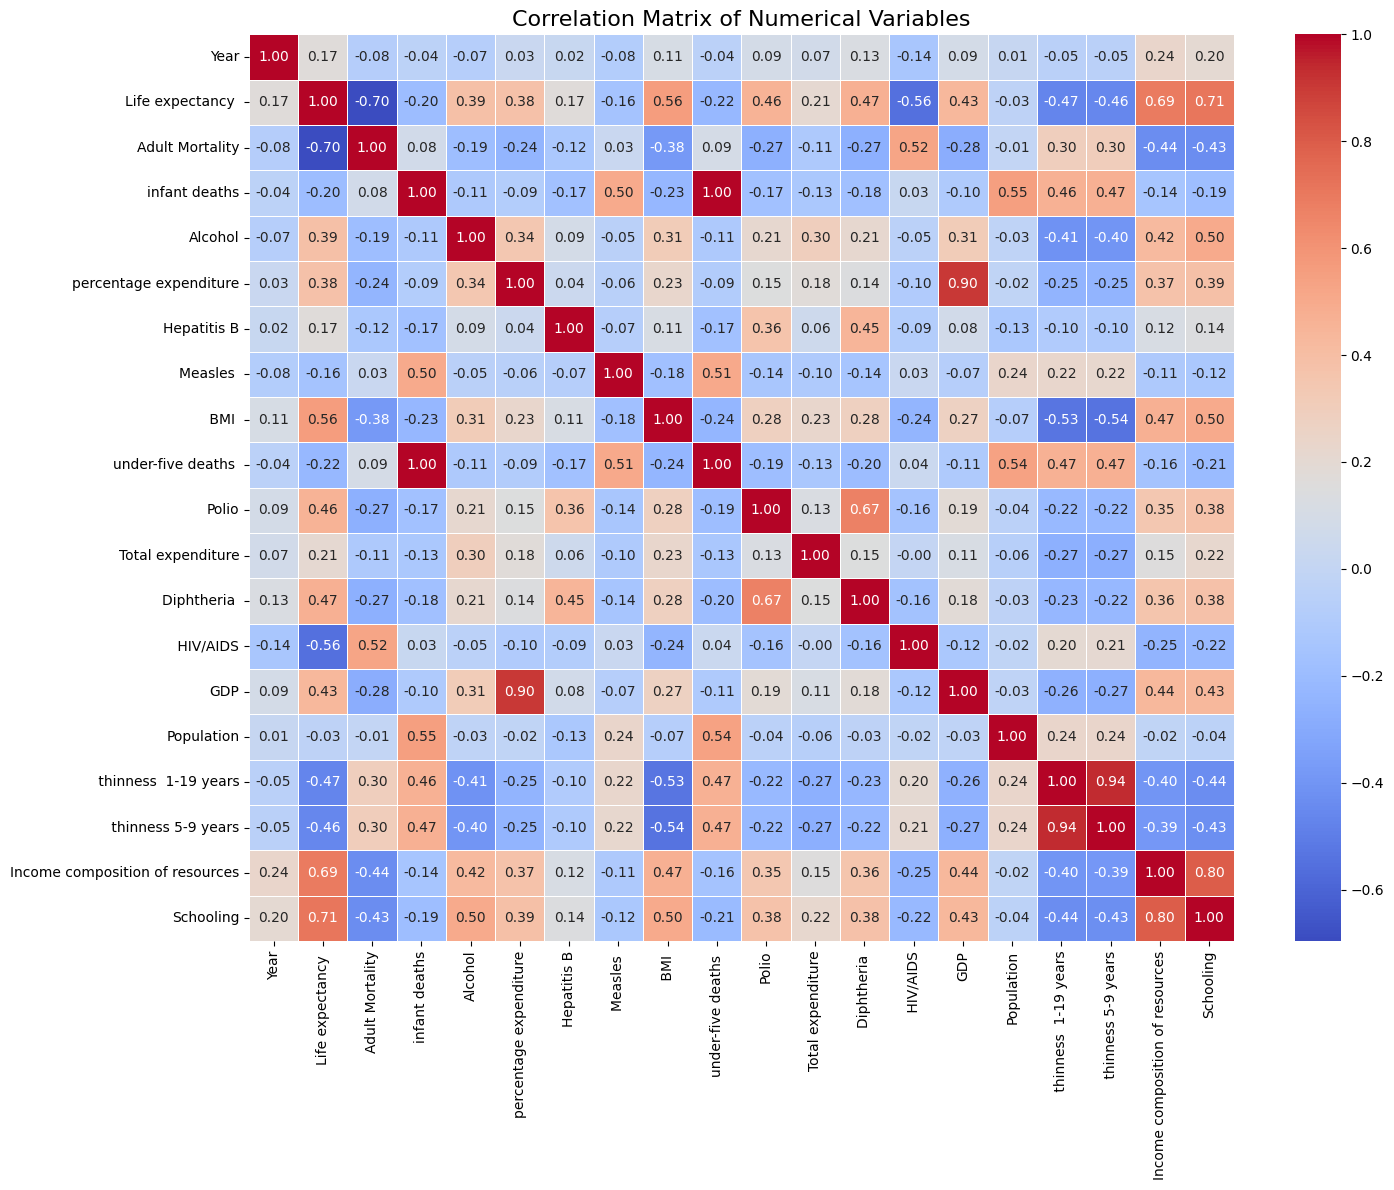

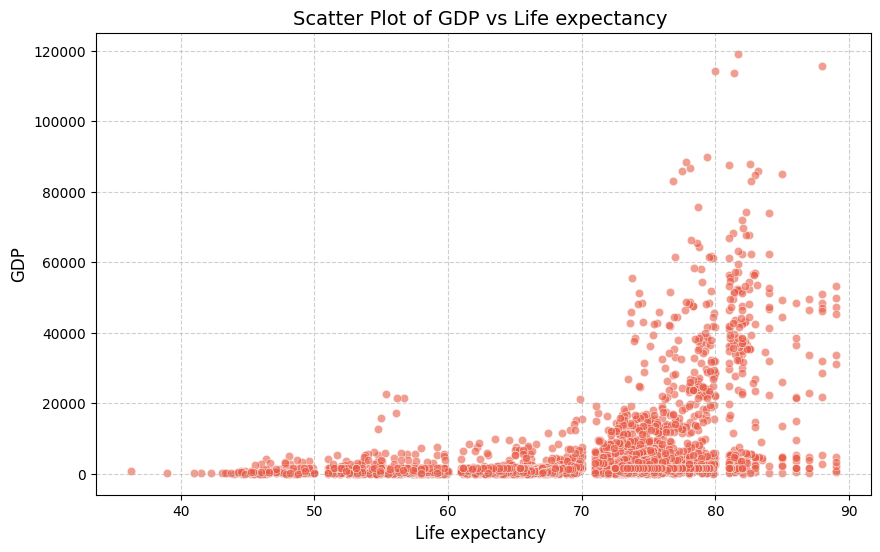

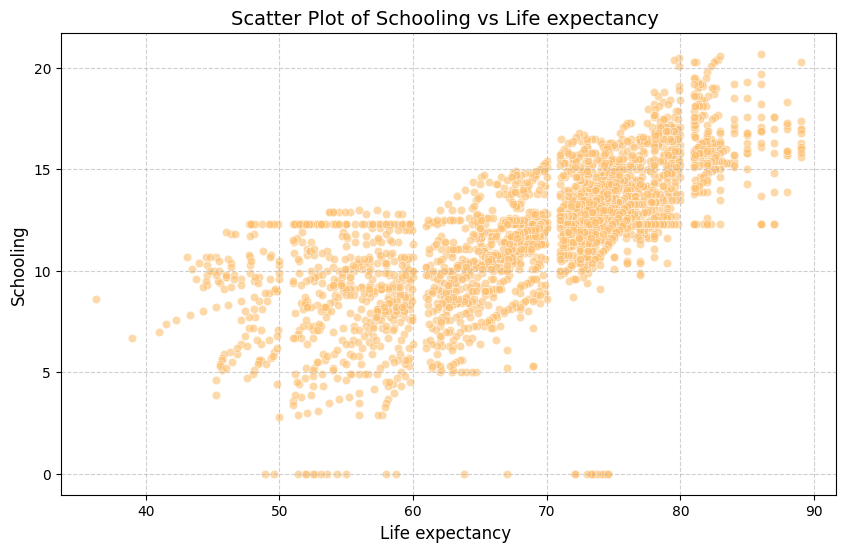

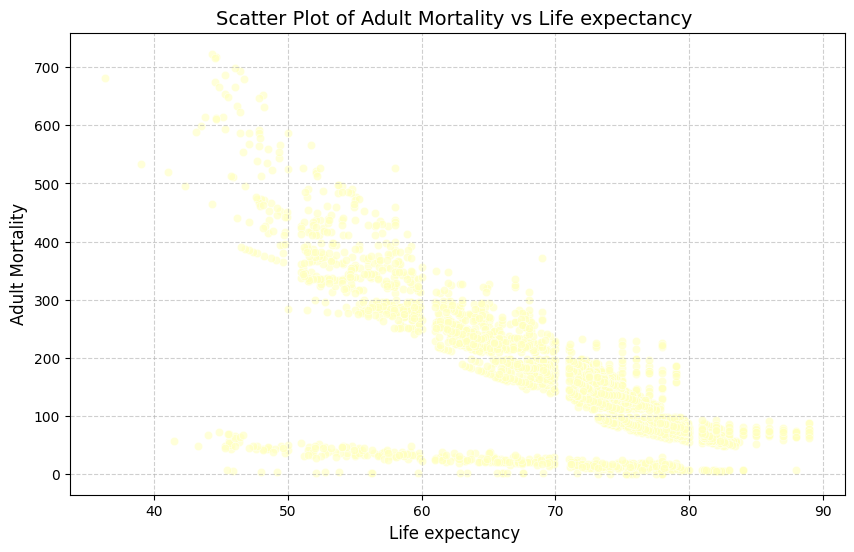

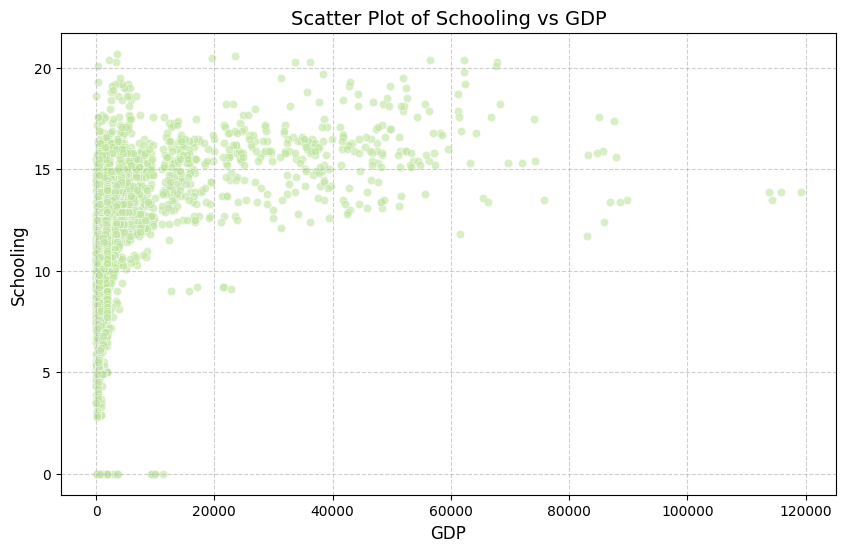

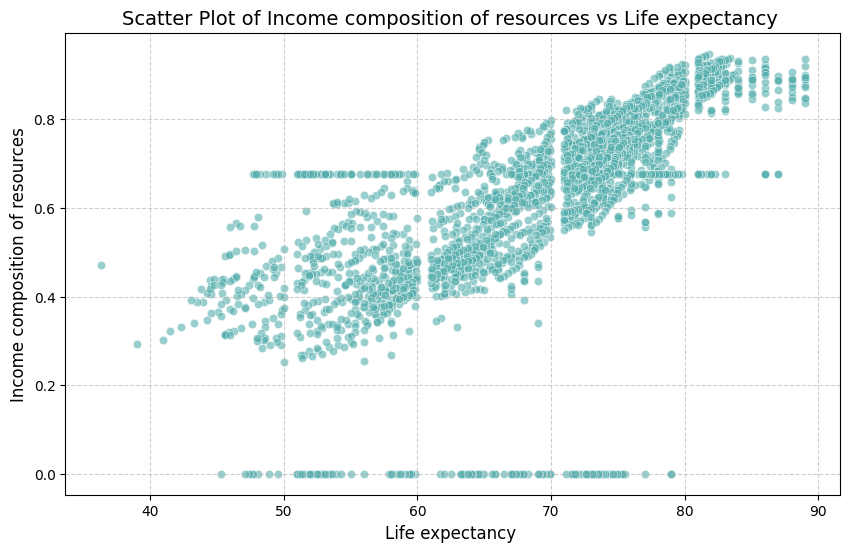

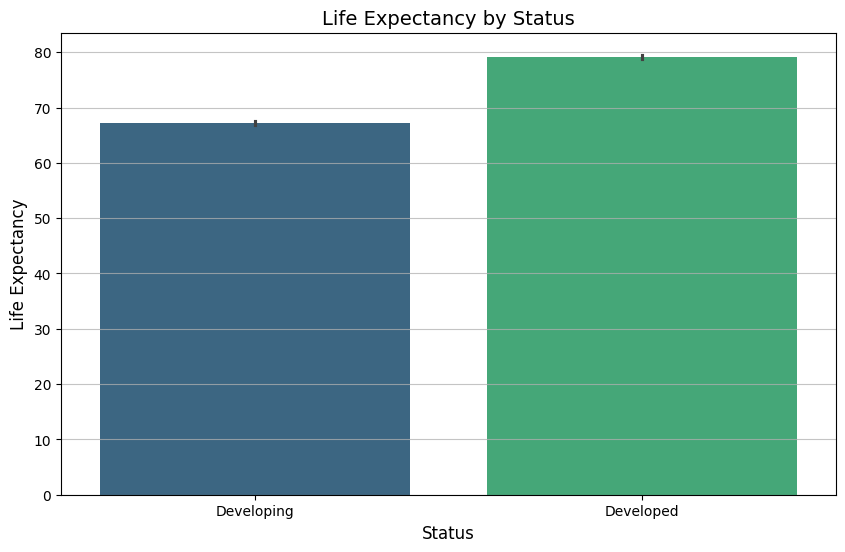

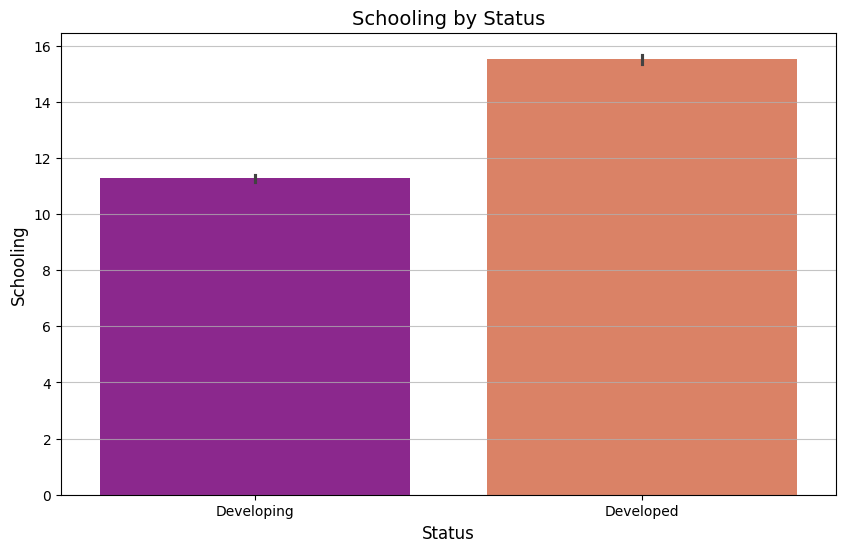

In [21]:
# 1. Create a correlation matrix for all numerical columns
numerical_cols = df_life.select_dtypes(include=np.number).columns
correlation_matrix = df_life[numerical_cols].corr()

# 2. Display the correlation matrix as a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Create scatter plots for key pairs of numerical variables
# Choose some pairs based on potential interest or high correlation from the matrix
scatter_pairs = [
    ('Life expectancy ', 'GDP'),
    ('Life expectancy ', 'Schooling'),
    ('Life expectancy ', 'Adult Mortality'),
    ('GDP', 'Schooling'),
    ('Life expectancy ', 'Income composition of resources')
]

# Define a color palette for scatter plots
scatter_color_palette = sns.color_palette("Spectral", len(scatter_pairs))

for i, (x_col, y_col) in enumerate(scatter_pairs):
    if x_col in numerical_cols and y_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_life, x=x_col, y=y_col, color=scatter_color_palette[i], alpha=0.6)
        plt.title(f'Scatter Plot of {y_col} vs {x_col}', fontsize=14)
        plt.xlabel(x_col, fontsize=12)
        plt.ylabel(y_col, fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
    else:
        print(f"Warning: One or both columns '{x_col}' or '{y_col}' not found in numerical columns.")


# 4. Use grouped bar plots to explore the relationship between a categorical variable and a numerical variable
# Example: Relationship between 'Status' (categorical) and 'Life expectancy ' (numerical)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_life, x='Status', y='Life expectancy ', palette='viridis', hue='Status', legend=False)
plt.title('Life Expectancy by Status', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Life Expectancy', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Another example: Relationship between 'Status' and 'Schooling'
plt.figure(figsize=(10, 6))
sns.barplot(data=df_life, x='Status', y='Schooling', palette='plasma', hue='Status', legend=False)
plt.title('Schooling by Status', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Schooling', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

## Bivariate analysis


In [9]:
# 1. Perform a t-test to compare the life expectancy between 'Developing' and 'Developed' countries.
# Separate life expectancy data for the two groups
life_exp_developing = df_life[df_life['Status'] == 'Developing']['Life expectancy ']
life_exp_developed = df_life[df_life['Status'] == 'Developed']['Life expectancy ']

# Perform independent samples t-test
ttest_result = stats.ttest_ind(life_exp_developing, life_exp_developed, nan_policy='omit')

print("Independent Samples t-test of Life Expectancy between Developing and Developed Countries:")
print(f"  T-statistic: {ttest_result.statistic:.4f}")
print(f"  P-value: {ttest_result.pvalue:.4f}")

# 2. Calculate the Pearson correlation coefficient and the p-value between 'Life expectancy ' and 'GDP'.
# Ensure both columns are numerical and handle potential missing values if any remain (though imputation was done)
life_exp = df_life['Life expectancy ']
gdp = df_life['GDP']

# Calculate Pearson correlation and p-value, handling potential NaN values
pearson_corr_gdp, p_value_gdp = stats.pearsonr(life_exp, gdp)

print("\nPearson Correlation between Life Expectancy and GDP:")
print(f"  Correlation Coefficient: {pearson_corr_gdp:.4f}")
print(f"  P-value: {p_value_gdp:.4f}")

# 3. Calculate the Pearson correlation coefficient and the p-value between 'Life expectancy ' and 'Schooling'.
schooling = df_life['Schooling']

# Calculate Pearson correlation and p-value, handling potential NaN values
pearson_corr_schooling, p_value_schooling = stats.pearsonr(life_exp, schooling)

print("\nPearson Correlation between Life Expectancy and Schooling:")
print(f"  Correlation Coefficient: {pearson_corr_schooling:.4f}")
print(f"  P-value: {p_value_schooling:.4f}")

Independent Samples t-test of Life Expectancy between Developing and Developed Countries:
  T-statistic: -29.7611
  P-value: 0.0000

Pearson Correlation between Life Expectancy and GDP:
  Correlation Coefficient: 0.4305
  P-value: 0.0000

Pearson Correlation between Life Expectancy and Schooling:
  Correlation Coefficient: 0.7131
  P-value: 0.0000


## Statistical tests


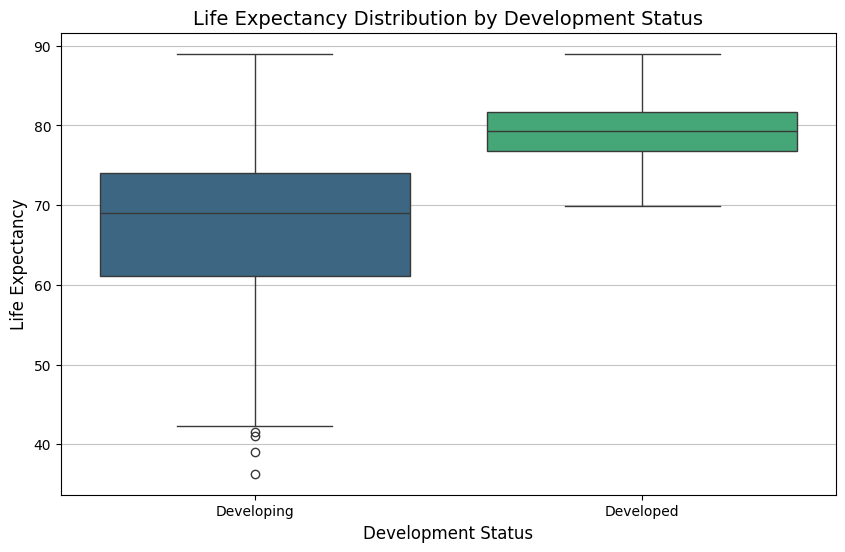

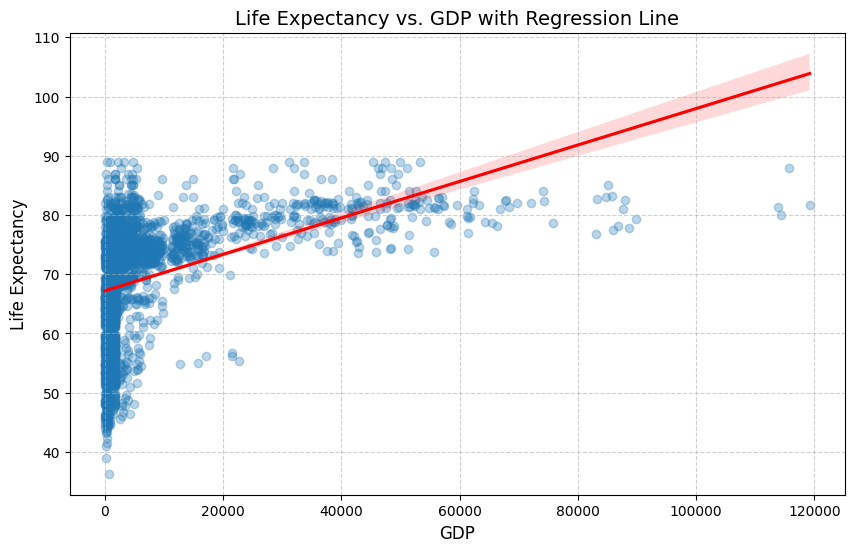

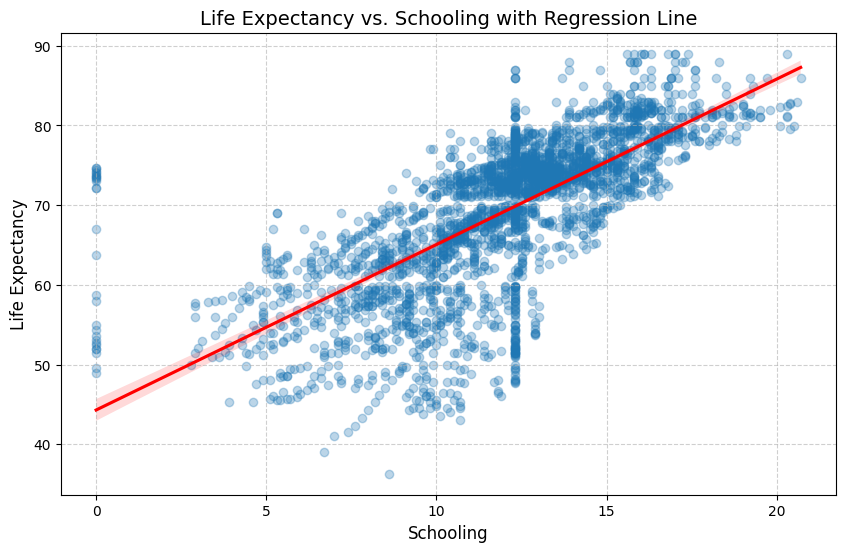

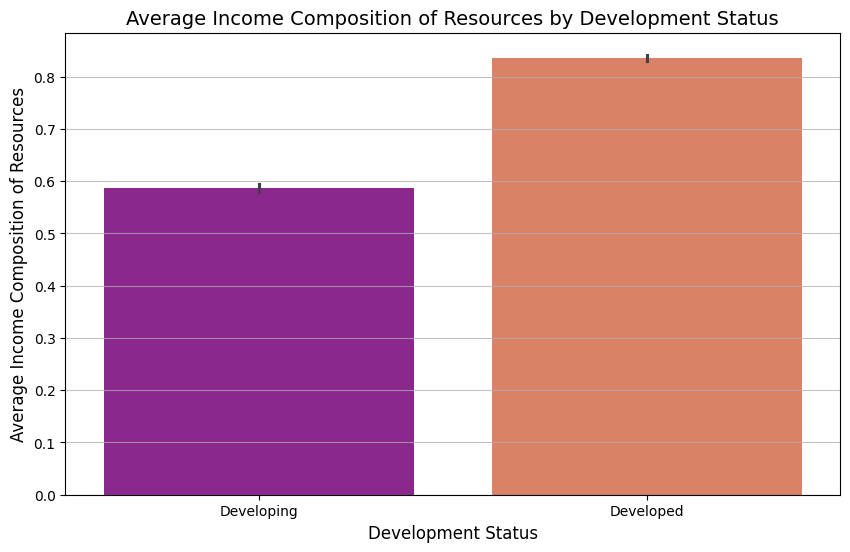

In [22]:
# 1. Box plot of 'Life expectancy ' by 'Status'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_life, x='Status', y='Life expectancy ', palette='viridis', hue='Status', legend=False)
plt.title('Life Expectancy Distribution by Development Status', fontsize=14)
plt.xlabel('Development Status', fontsize=12)
plt.ylabel('Life Expectancy', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Scatter plot with regression line for 'Life expectancy ' vs 'GDP'
plt.figure(figsize=(10, 6))
sns.regplot(data=df_life, x='GDP', y='Life expectancy ', scatter_kws={'alpha':0.3}, line_kws={"color": "red"})
plt.title('Life Expectancy vs. GDP with Regression Line', fontsize=14)
plt.xlabel('GDP', fontsize=12)
plt.ylabel('Life Expectancy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Scatter plot with regression line for 'Life expectancy ' vs 'Schooling'
plt.figure(figsize=(10, 6))
sns.regplot(data=df_life, x='Schooling', y='Life expectancy ', scatter_kws={'alpha':0.3}, line_kws={"color": "red"})
plt.title('Life Expectancy vs. Schooling with Regression Line', fontsize=14)
plt.xlabel('Schooling', fontsize=12)
plt.ylabel('Life Expectancy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Bar plot of average 'Income composition of resources' by 'Status'
plt.figure(figsize=(10, 6))
sns.barplot(data=df_life, x='Status', y='Income composition of resources', palette='plasma', hue='Status', legend=False)
plt.title('Average Income Composition of Resources by Development Status', fontsize=14)
plt.xlabel('Development Status', fontsize=12)
plt.ylabel('Average Income Composition of Resources', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

## Visualization


## Summarize findings

### Subtask:
Provide a summary of the key insights and conclusions drawn from the analysis.


## Summary:

### Data Analysis Key Findings

*   No columns had a percentage of missing values exceeding the defined threshold of 50%, so no columns were dropped during missing value handling.
*   Missing numerical values were imputed using the median for their respective columns.
*   The data types of the columns were appropriate upon loading, requiring no conversion.
*   Descriptive statistics for numerical columns and frequency counts for categorical columns were successfully generated.
*   Visual analysis showed the distribution of individual numerical and categorical variables through histograms, box plots, and count plots.
*   A strong positive correlation (0.7131) was found between Life expectancy and Schooling.
*   A moderate positive correlation (0.4305) was found between Life expectancy and GDP.
*   An independent samples t-test revealed a statistically significant difference in Life expectancy between 'Developing' and 'Developed' countries (p-value < 0.0001).
*   Visualizations, including box plots and scatter plots with regression lines, supported the statistical findings regarding the relationship between Life expectancy, development status, GDP, and Schooling.

### Insights

*   Investigate the nature of the outliers identified in the box plots of numerical variables and determine if they warrant specific handling or further investigation.
*   Explore potential multivariate relationships and build a predictive model for Life expectancy using the identified significant factors and other relevant variables.
